In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout, BatchNormalization, Dense, Input
from tensorflow.keras.regularizers import l2

## Task 1: Exploratory Data Analysis (EDA)

Goal: understand the target (SalePrice), check skewness/outliers, inspect key relationships (size/rooms/location),
review correlations, and decide how to handle missing values and categorical features before modeling.

### Loading and inspecting datas set

The Ames Housing dataset consists of 2930 observations and 82 features. Each observation corresponds to a single house, while the features describe different characteristics of the property. The target variable for this regression task is SalePrice, which represents the house price. Summary statistics are used to get an overview of the range, typical values, and variation in house prices.

In [3]:
df_housing= pd.read_csv("AmesHousing.csv")
df_housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df_housing.shape

(2930, 82)

In [ ]:
df_housing.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [ ]:
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [ ]:
df_housing["SalePrice"].describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


House prices vary a lot (not evenly distributed). Mean around 181,000 and median around 160,000. The maximum price is much higher than the average, indicating the presence of high-price outliers and a right-skewed distribution (mean > median).

### Price distribution, skewnes, outliers
The distribution of SalePrice is explored to see whether the data is skewed and if there are any extreme values. Since the distribution is right-skewed, a logarithmic transformation is applied to make it more symmetric. This helps reduce the influence of very high house prices and can improve the performance of regression models.

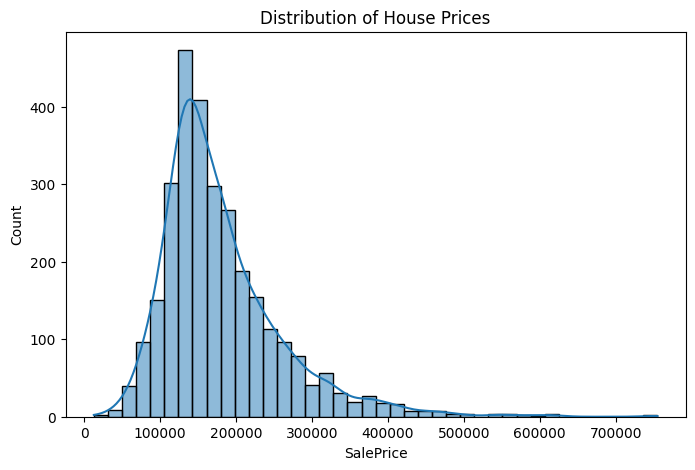

SalePrice skewness: 1.7435000757376466


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_housing['SalePrice'], kde=True, bins=40)
plt.title("Distribution of House Prices")
plt.show()

skewness = df_housing["SalePrice"].skew()
print("SalePrice skewness:", skewness)

In [4]:
df_housing['SalePrice_Log'] = np.log1p(df_housing['SalePrice'])

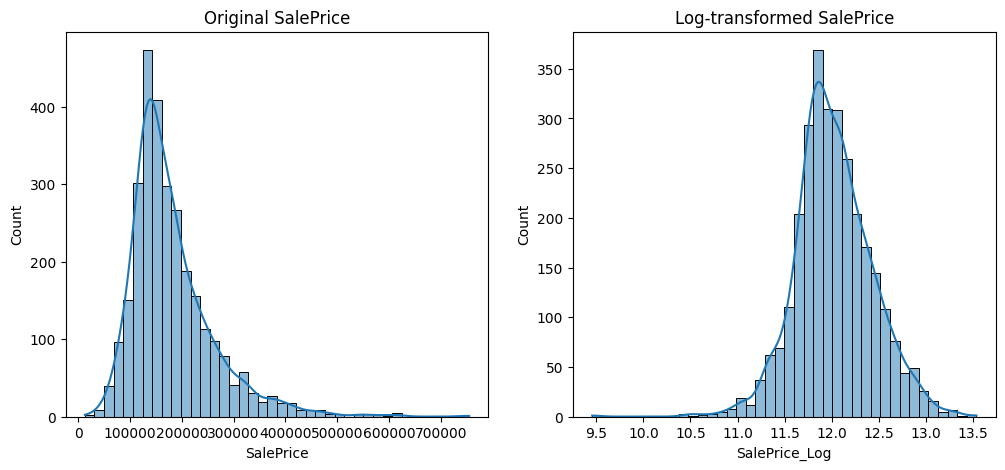

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_housing['SalePrice'], kde=True, bins=40)
plt.title("Original SalePrice")

plt.subplot(1,2,2)
sns.histplot(df_housing['SalePrice_Log'], kde=True, bins=40)
plt.title("Log-transformed SalePrice")
plt.show()

### Relationships: Size, Rooms, Location
To better understand the drivers of house prices, we explore the relationship between SalePrice and
key variables related to size, number of rooms, and location.

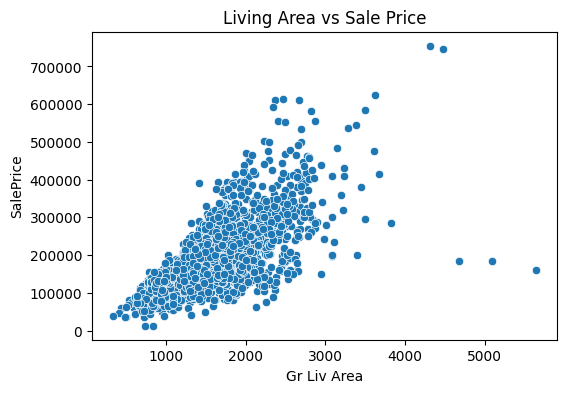

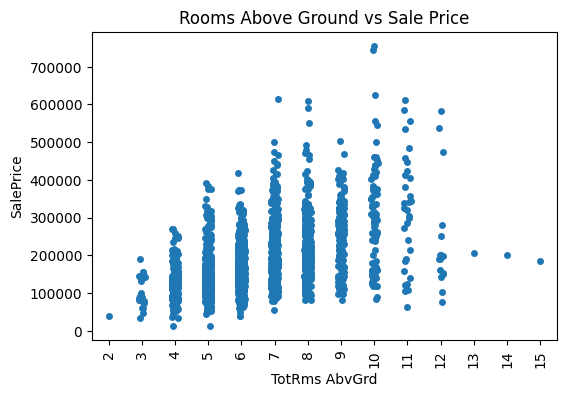

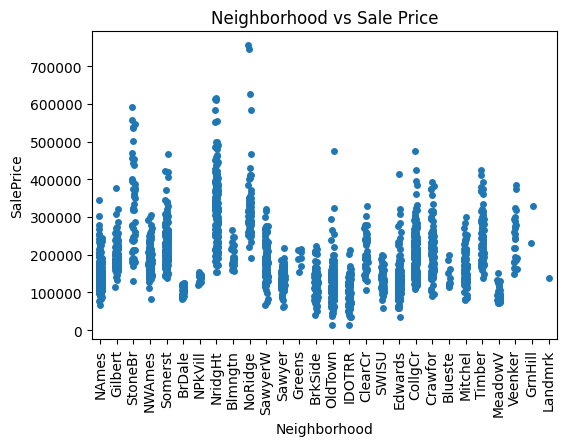

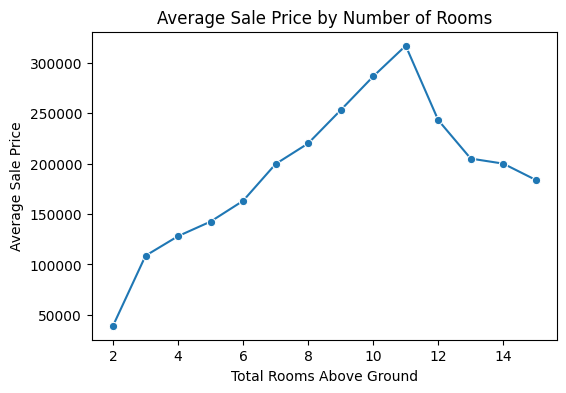

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_housing['Gr Liv Area'], y=df_housing['SalePrice'])
plt.title("Living Area vs Sale Price")
plt.show()

plt.figure(figsize=(6,4))
sns.stripplot(x=df_housing['TotRms AbvGrd'], y=df_housing['SalePrice'], jitter=True)
plt.xticks(rotation=90)
plt.title("Rooms Above Ground vs Sale Price")
plt.show()

plt.figure(figsize=(6,4))
sns.stripplot(x=df_housing['Neighborhood'], y=df_housing['SalePrice'], jitter=True)
plt.xticks(rotation=90)
plt.title("Neighborhood vs Sale Price")
plt.show()

room_price = df_housing.groupby("TotRms AbvGrd")["SalePrice"].mean()

plt.figure(figsize=(6,4))
sns.lineplot(x=room_price.index, y=room_price.values, marker="o")
plt.xlabel("Total Rooms Above Ground")
plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by Number of Rooms")
plt.show()


###Feature relationships and correlation analysis
Relationships between selected features and SalePrice are explored to see which variables are most important for predicting house prices. Features related to house size and overall quality show strong relationships with price. A correlation heatmap of the top numerical features is used to compare the strength of these relationships and to identify features that may capture similar information (identify potential redundancy).

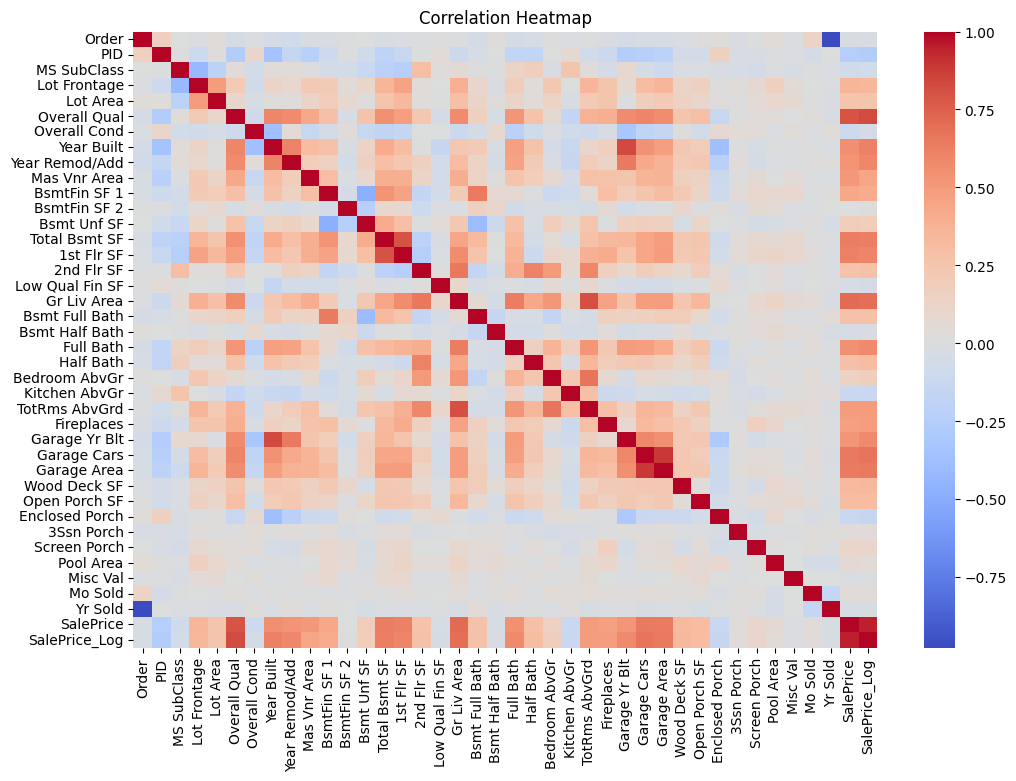

In [5]:
plt.figure(figsize=(12,8))
corr = df_housing.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [6]:
# Top 10 correlated numeric features with SalePrice
corr_target = (
    df_housing
    .corr(numeric_only=True)["SalePrice_Log"]
    .sort_values(key=abs, ascending=False)
)

top10 = corr_target[2:12]  # exclude SalePrice itself

print("Top 10 correlated numeric features with SalePrice_Log:")
print(top10)


Top 10 correlated numeric features with SalePrice_Log:
Overall Qual      0.825645
Gr Liv Area       0.695863
Garage Cars       0.675318
Garage Area       0.651132
Total Bsmt SF     0.625099
Year Built        0.615485
1st Flr SF        0.602629
Year Remod/Add    0.586153
Garage Yr Blt     0.580502
Full Bath         0.577335
Name: SalePrice_Log, dtype: float64


Several size and quality related numerical features show strong positive correlation with SalePrice_Log, indicating their importance for predicting house prices.

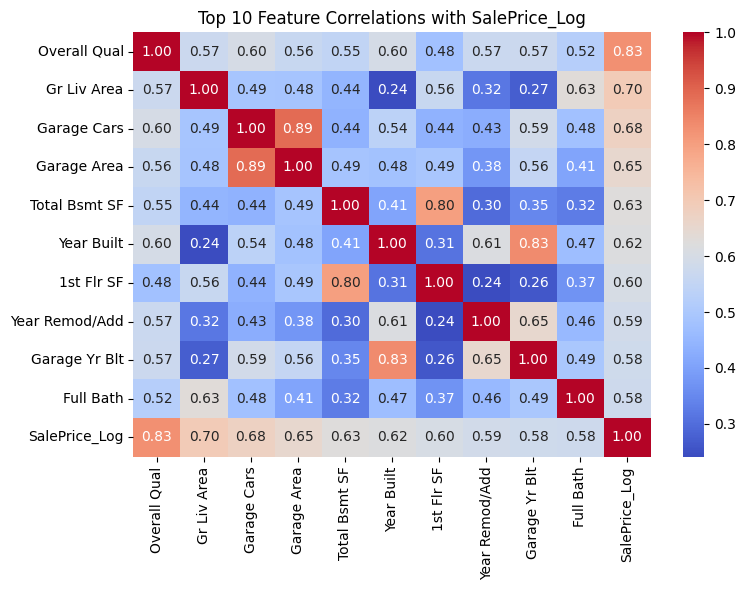

In [7]:
# Top10 correlated numeric features with SalePrice heatmap
top10_features = top10.head(10).index.tolist()

heatmap_df = df_housing[top10_features + ["SalePrice_Log"]]

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Top 10 Feature Correlations with SalePrice_Log")
plt.tight_layout()
plt.show()


The heatmap shows that SalePrice_Log is most strongly correlated with quality- and size-related features such as Overall Qual, Gr Liv Area, and garage and basement size. Several predictors are also strongly correlated with each other, indicating potential redundancy.

### Preprocessing
Several features in the dataset contain missing values, which means that some form of imputation will be needed during preprocessing. The dataset includes both numerical and categorical variables, such as continuous features like house size and discrete ordinal features like overall quality.

In [ ]:
df = df_housing.drop(columns=["Order", "PID"])

In [ ]:
# Removing outliers
df = df[df["Gr Liv Area"] < 4000]

In [ ]:
# Count missing values
missing_counts = df.isnull().sum()
dtypes = df.dtypes

# Combine into one DataFrame
missing_summary = pd.DataFrame({
    'MissingValues': missing_counts,
    'DataType': dtypes
})

missing_summary = missing_summary[missing_summary['MissingValues'] > 0] \
                                   .sort_values(by='MissingValues', ascending=False)

print(missing_summary)


                MissingValues DataType
Pool QC                  2914   object
Misc Feature             2820   object
Alley                    2727   object
Fence                    2354   object
Mas Vnr Type             1774   object
Fireplace Qu             1422   object
Lot Frontage              490  float64
Garage Qual               159   object
Garage Cond               159   object
Garage Yr Blt             159  float64
Garage Finish             159   object
Garage Type               157   object
Bsmt Exposure              83   object
BsmtFin Type 2             81   object
Bsmt Cond                  80   object
Bsmt Qual                  80   object
BsmtFin Type 1             80   object
Mas Vnr Area               23  float64
Bsmt Full Bath              2  float64
Bsmt Half Bath              2  float64
BsmtFin SF 1                1  float64
BsmtFin SF 2                1  float64
Electrical                  1   object
Total Bsmt SF               1  float64
Bsmt Unf SF              

27 features contain missing values. To handle missing values, we will implement a Hybrid Imputation Strategy: categorical 'NaNs' will be mapped to 'None' to represent the absence of a feature, and numerical 'NaNs' will be mapped to '0' where logically appropriate (e.g., Garage Area).

### Train/Test Split

In [ ]:
# Create stratification bins from target
price_bins = pd.qcut(df['SalePrice_Log'], q=4, duplicates='drop')

# Train-test split with stratification
X = df.drop(['SalePrice', 'SalePrice_Log'], axis=1)
y = df['SalePrice_Log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=price_bins
)


In [ ]:
# Verify that each price quartile has ~25% representation in both sets
strat_verification = pd.DataFrame({
    "Train %": price_bins.loc[y_train.index].value_counts(normalize=True).sort_index() * 100,
    "Test %":  price_bins.loc[y_test.index].value_counts(normalize=True).sort_index() * 100
})

print("Stratification Verification (Quartiles):")
print(strat_verification)

Stratification Verification (Quartiles):
                    Train %     Test %
SalePrice_Log                         
(9.455, 11.771]   25.256410  25.299145
(11.771, 11.983]  24.871795  24.786325
(11.983, 12.271]  24.957265  24.957265
(12.271, 13.346]  24.914530  24.957265


The table above confirms that the train and test sets have nearly identical distributions across price bins, indicating that stratified splitting was successful.

### Missing Value Treatment
We calculate the median using only the training data. This ensures that information from the test set (the "unseen" data) does not influence your training process.





In [ ]:
# Compute medians from terain
frontage_median = (
    X_train.groupby("Neighborhood")["Lot Frontage"].median()
)

# Apply to train
X_train["Lot Frontage"] = X_train["Lot Frontage"].fillna(
    X_train["Neighborhood"].map(frontage_median)
)

# Apply to test
X_test["Lot Frontage"] = X_test["Lot Frontage"].fillna(
    X_test["Neighborhood"].map(frontage_median)
)

#Covering records where Neighborhood information missing
global_median = X_train["Lot Frontage"].median()

X_train["Lot Frontage"] = X_train["Lot Frontage"].fillna(global_median)
X_test["Lot Frontage"]  = X_test["Lot Frontage"].fillna(global_median)


# Numeric fill with 0
num_zero = ['Mas Vnr Area','Bsmt Full Bath','Bsmt Half Bath','BsmtFin SF 1','BsmtFin SF 2',
            'Bsmt Unf SF','Garage Area','Garage Cars','Total Bsmt SF','Garage Yr Blt']
for col in num_zero:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)


# Electrical: fill with mode
electrical_mode = X_train["Electrical"].mode()[0]

X_train["Electrical"] = X_train["Electrical"].fillna(electrical_mode)
X_test["Electrical"]  = X_test["Electrical"].fillna(electrical_mode)



In [ ]:
# Categorical "None"
cat_none = ['Pool QC','Misc Feature','Alley','Fence','Mas Vnr Type','Fireplace Qu',
            'Garage Qual','Garage Cond','Garage Finish','Garage Type',
            'Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Bsmt Cond','Bsmt Qual']
for col in cat_none:
    X_train[col] = X_train[col].fillna("None")
    X_test[col]  = X_test[col].fillna("None")

In [ ]:
#Preservig order of quality
quality_map = {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5}

for col in ['Exter Qual','Exter Cond','Kitchen Qual','Heating QC']:
    X_train[col] = X_train[col].map(quality_map).fillna(0)
    X_test[col]  = X_test[col].map(quality_map).fillna(0)

In [ ]:
#Ensuring feature aligment
# Identify categorical columns from train
cat_cols = X_train.select_dtypes(include=['object']).columns

# One-hot encode train and test separately
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align columns so train/test match
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [ ]:
X_train.shape

(2340, 260)

### Feature Screening and Selection
One-hot encoding increased our feature count to 260, creating a risk of the model 'memorizing' noise. We use feature selection to remove redundant variables and keep only those with a significant correlation or importance score, leading to a more robust and generalizable model

                Correlation  RandomForestImportance
Overall Qual       0.822220                0.612619
Gr Liv Area        0.702101                0.082487
Garage Area        0.645917                0.040900
Total Bsmt SF      0.629905                0.033112
Garage Cars        0.662960                0.024959
1st Flr SF         0.598026                0.020483
Lot Area           0.264509                0.017895
BsmtFin SF 1       0.405331                0.016313
Year Built         0.607036                0.012551
Year Remod/Add     0.583821                0.011639
Garage Yr Blt      0.333222                0.007383
Overall Cond      -0.032018                0.007376
Full Bath          0.574627                0.007266
Kitchen Qual       0.659034                0.005378
Lot Frontage       0.343801                0.005053
Bsmt Unf SF        0.190157                0.004892
2nd Flr SF         0.290357                0.004644
MS Zoning_RM      -0.351926                0.004056
Open Porch S

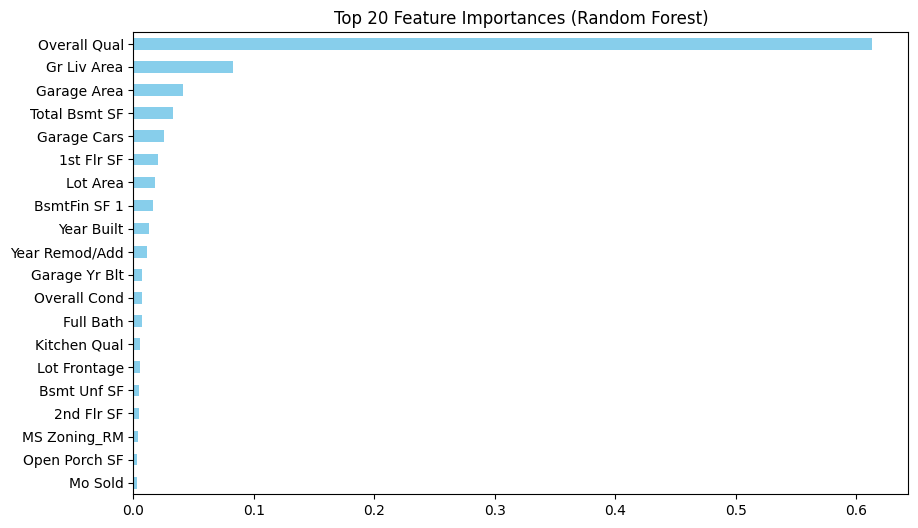

In [ ]:
# Feature importance and correlation are used as a filtering step to guide feature selection.

# Random Forest for feature importance
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns, name="RandomForestImportance")

# Correlation with target (numeric only)
corr_importances = (X_train.join(y_train)).corr(numeric_only=False)['SalePrice_Log']
corr_importances = corr_importances.rename("Correlation")

# Combine into one DataFrame
importance_table = pd.concat([corr_importances, rf_importances], axis=1)

# Sort by Random Forest importance
importance_table = importance_table.sort_values(by='RandomForestImportance', ascending=False)

# Print top 20 features
print(importance_table.head(20))

# Plot top 20 features
top_features = importance_table.head(20)

plt.figure(figsize=(10,6))
top_features['RandomForestImportance'].plot(kind='barh', color='skyblue')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


## Feature selection
We chose a dual-filtering approach using both Pearson Correlation and Random Forest Feature Importance to capture different types of relationships within the data:
*   **Correlation** identifies strong linear relationships.
*   **Random Forest Importance** identifies non-linear relationships and complex interactions.

By combining these two metrics, we create a robust filter. This ensures our final model is fed a feature set that is not only statistically relevant but also captures the complex, real-world nuances of the housing market.

In [ ]:
# Define thresholds
corr_threshold = 0.3   # keep features with correlation >= 0.3
rf_threshold   = 0.005  # keep features with RF importance >= 0.005

# Select features meeting either criterion
selected_features = importance_table[
    (importance_table['Correlation'].abs() >= corr_threshold) |
    (importance_table['RandomForestImportance'] >= rf_threshold)
].index.tolist()

selected_features = [f for f in selected_features if f not in ['SalePrice','SalePrice_Log']]

print("Selected features:", selected_features)

# Trim dataset to selected features
X_train = X_train[selected_features]
X_test  = X_test[selected_features]


Selected features: ['Overall Qual', 'Gr Liv Area', 'Garage Area', 'Total Bsmt SF', 'Garage Cars', '1st Flr SF', 'Lot Area', 'BsmtFin SF 1', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Overall Cond', 'Full Bath', 'Kitchen Qual', 'Lot Frontage', 'MS Zoning_RM', 'Open Porch SF', 'Mas Vnr Area', 'Central Air_Y', 'Heating QC', 'Wood Deck SF', 'Paved Drive_Y', 'Fireplaces', 'Garage Cond_TA', 'TotRms AbvGrd', 'MS Zoning_RL', 'Exter Qual', 'Fireplace Qu_None', 'Garage Type_Detchd', 'Bsmt Qual_Gd', 'Garage Finish_Unf', 'Lot Shape_Reg', 'Half Bath', 'Fireplace Qu_Gd', 'Bsmt Exposure_Gd', 'Foundation_PConc', 'Bsmt Qual_TA', 'BsmtFin Type 1_GLQ', 'Foundation_CBlock', 'Garage Type_Attchd', 'Exterior 1st_VinylSd', 'Exterior 2nd_VinylSd', 'Mas Vnr Type_None', 'Garage Qual_None', 'Garage Qual_TA', 'Neighborhood_NridgHt', 'Sale Condition_Partial', 'Sale Type_New', 'Garage Finish_None', 'Garage Type_None', 'Garage Cond_None']


## Task 2:Shallow learners
Goal:To train and evaluate classical regression models to predict Sale Price_Log.Report MAE, RMSE and R2 on the test set. Include an ensemble model (stacking) and analyze prediction errors across different price ranges.

In [ ]:
# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

### Linear Regression

In [ ]:
# Baseline Linear Regression
linreg_base = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])
linreg_base.fit(X_train, y_train)
y_pred_base = linreg_base.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = linreg_base.score(X_test, y_test)

print(f"Baseline Linear Regression → RMSE: {rmse_base:.3f}, MAE: {mae_base:.3f}, R2: {r2_base:.3f}")


Baseline Linear Regression → RMSE: 0.111, MAE: 0.079, R2: 0.925


Our Linear Regression model achieves a surprisingly strong baseline performance. This indicates that our preprocessing pipeline effectively linearized the relationships between the predictors and the target variable

### Random Forest

In [ ]:
# Base RF model
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = rf_base.score(X_test, y_test)

print(f"Baseline RF → RMSE: {rmse_base:.3f}, MAE: {mae_base:.3f}, R2: {r2_base:.3f}")


Baseline RF → RMSE: 0.125, MAE: 0.085, R2: 0.906


In [ ]:
# Random Forest Grid Search
rf = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [4, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(rf, rf_param_grid, cv=cv,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
rf_best = rf_grid.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


### Gradient Boosting

In [ ]:
# Baseline Gradient Boosting Model
gb_base = GradientBoostingRegressor(random_state=42)
gb_base.fit(X_train, y_train)
y_pred_base = gb_base.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = gb_base.score(X_test, y_test)

print(f"Baseline GB → RMSE: {rmse_base:.3f}, MAE: {mae_base:.3f}, R2: {r2_base:.3f}")

Baseline GB → RMSE: 0.114, MAE: 0.078, R2: 0.922


In [ ]:
# Gradient Boosting Grid Search
gb = GradientBoostingRegressor(random_state=42)
gb_param_grid = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.005, 0.01, 0.05],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 0.9]
}
gb_grid = GridSearchCV(gb, gb_param_grid, cv=cv,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print("Best GB params:", gb_grid.best_params_)
gb_best = gb_grid.best_estimator_


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best GB params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


Both Global search and Local Refirement were used to maximez the usefullnes of grid search. Exploring the parameter space more deeply without, ensuring we captured the most precise version of our best-performing models.

In [ ]:
# Recreate models from best parameters
rf_best = RandomForestRegressor(
    max_depth= 20,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=100,
    random_state=42
)
gb_best = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)

# Fit them once on your training data
gb_best.fit(X_train, y_train)
rf_best.fit(X_train, y_train)


RandomForestRegressor(max_depth=20, min_samples_split=5, random_state=42)

We recreate the best performing models from the GridSearch results so have to run it only once.

### Base vs Tuned
A simple performance metrics comparisont to evaluate the effect of hyperparameter tuning. From the results we can observe that although the effect was minimal it helped to improve the performance.

In [ ]:
# Baseline vs Tuned model comparison

models_compare = {
    "RF Baseline": rf_base,
    "RF Tuned": rf_best,
    "GB Baseline": gb_base,
    "GB Tuned": gb_best
}

for name, model in models_compare.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = model.score(X_test, y_test)
    print(f"{name} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")


RF Baseline → RMSE: 0.125, MAE: 0.085, R2: 0.906
RF Tuned → RMSE: 0.124, MAE: 0.085, R2: 0.907
GB Baseline → RMSE: 0.114, MAE: 0.078, R2: 0.922
GB Tuned → RMSE: 0.111, MAE: 0.077, R2: 0.926


### Ensemble
Final Ensemble: We use a StackingRegressor with 5-fold cross-validation. It uses our tuned Random Forest and Gradient Boosting models as base estimators and a Linear Regression meta-model to produce the final price prediction. This architecture aims to achieve the lowest possible RMSE by combining the diverse predictive patterns of the base models.

In [ ]:
# Base learners: best models from grid search
estimators = [
    ('rf', rf_best),
    ('gb', gb_best)
]

# Meta-learner: simple linear regression
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

# Fit ensemble
stack.fit(X_train, y_train)

# Evaluate
y_pred_stack = stack.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mae_stack = mean_absolute_error(y_test, y_pred_stack)
r2_stack= stack.score(X_test, y_test)
print(f"Stacked Ensemble → RMSE: {rmse_stack:.3f}, MAE: {mae_stack:.3f}, R2: {r2_stack:.3f}")


Stacked Ensemble → RMSE: 0.111, MAE: 0.077, R2: 0.926


In [ ]:
# Evaluate models
for name, model in [('Random Forest', rf_best),
                    ('Gradient Boosting', gb_best),
                    ('Linear regression',linreg_base ),
                    ('Stacking Ensemble',stack )]:
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = model.score(X_test, y_test)
    print(f"{name} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")

Random Forest → RMSE: 0.124, MAE: 0.085, R2: 0.907
Gradient Boosting → RMSE: 0.111, MAE: 0.077, R2: 0.926
Linear regression → RMSE: 0.111, MAE: 0.079, R2: 0.925
Stacking Ensemble → RMSE: 0.111, MAE: 0.077, R2: 0.926


Finnaly we compare performance over all shallow learners where we observe the top models beeing Gradient Boosting and Stacking Ensamble.Since the Stacked Ensemble did not provide a significant uplift over the standalone Gradient Boosting model, the GB model could be considered the preferred model. It offers the same predictive power with less computational complexity and a simpler pipeline

### Prediction error analysis
Sale Price prediction error will inform us of how the different models perform in the 4 price ranges: low, mid-low, mid-high and high.

/tmp/ipython-input-812967605.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_summary = errors.groupby('price_range')[['rf_error','gb_error','linreg_error','stack_error']].mean()


                       RMSE       MAE
Random Forest      0.124369  0.085085
Gradient Boosting  0.111091  0.076629
Linear Regression  0.111345  0.079014
Stacking Ensemble  0.111055  0.076611


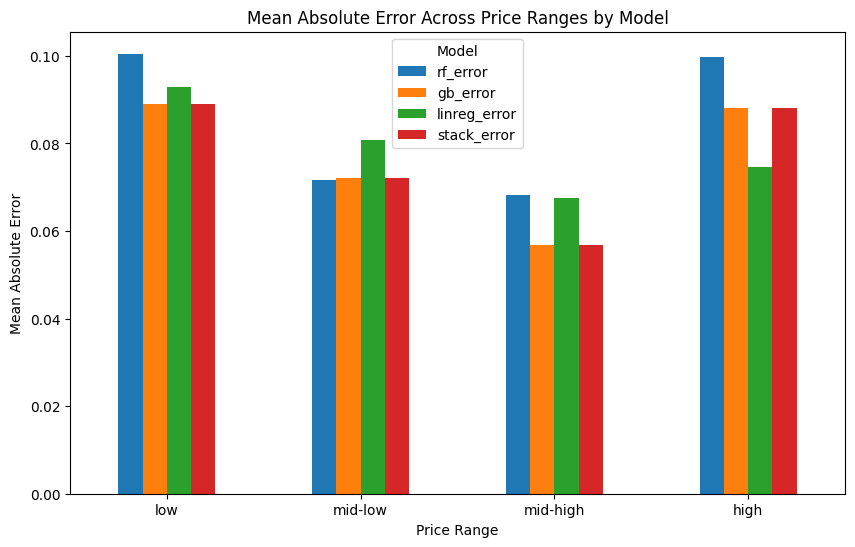

In [ ]:
# Predictions from each model
y_pred_rf = rf_best.predict(X_test)
y_pred_gb = gb_best.predict(X_test)
y_pred_base = linreg_base.predict(X_test)
y_pred_stack = stack.predict(X_test)

# Metrics
metrics = {
    'Random Forest': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'MAE': mean_absolute_error(y_test, y_pred_rf)
    },
    'Gradient Boosting': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        'MAE': mean_absolute_error(y_test, y_pred_gb)
    },
    'Linear Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_base)),
        'MAE': mean_absolute_error(y_test, y_pred_base)
    },
    'Stacking Ensemble': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_stack)),
        'MAE': mean_absolute_error(y_test, y_pred_stack)
    }
}

# Build DataFrame with true values
errors = pd.DataFrame({'true': y_test})
errors['rf'] = y_pred_rf
errors['gb'] = y_pred_gb
errors['linreg'] = y_pred_base
errors['stack'] = y_pred_stack

# Absolute errors
errors['rf_error'] = np.abs(errors['true'] - errors['rf'])
errors['gb_error'] = np.abs(errors['true'] - errors['gb'])
errors['linreg_error'] = np.abs(errors['true'] - errors['linreg'])
errors['stack_error'] = np.abs(errors['true'] - errors['stack'])

# Bin target values into ranges (quartiles here)
errors['price_range'] = pd.qcut(errors['true'], q=4, labels=['low','mid-low','mid-high','high'])

# Group by price range and compute mean errors
error_summary = errors.groupby('price_range')[['rf_error','gb_error','linreg_error','stack_error']].mean()

#table
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

# Plot grouped bar chart
error_summary.plot(kind='bar', figsize=(10,6))
plt.title("Mean Absolute Error Across Price Ranges by Model")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Price Range")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()


Overall the error rates are higher for low and high price ranges for all models and more stabile for the mid price ranges. Ensemble and Gradient Boosting atchieve near identical performance across all groups but Stacking Ensemble shows slightly lower residual RMSE and MAE, indicating both reduced error variance and improved average prediction accuracy.

### SHAP
SHAP analysis reveals that house prices are primarly driven by overall construction quality, living space, and basement size, followed by age-related features and key amenities.

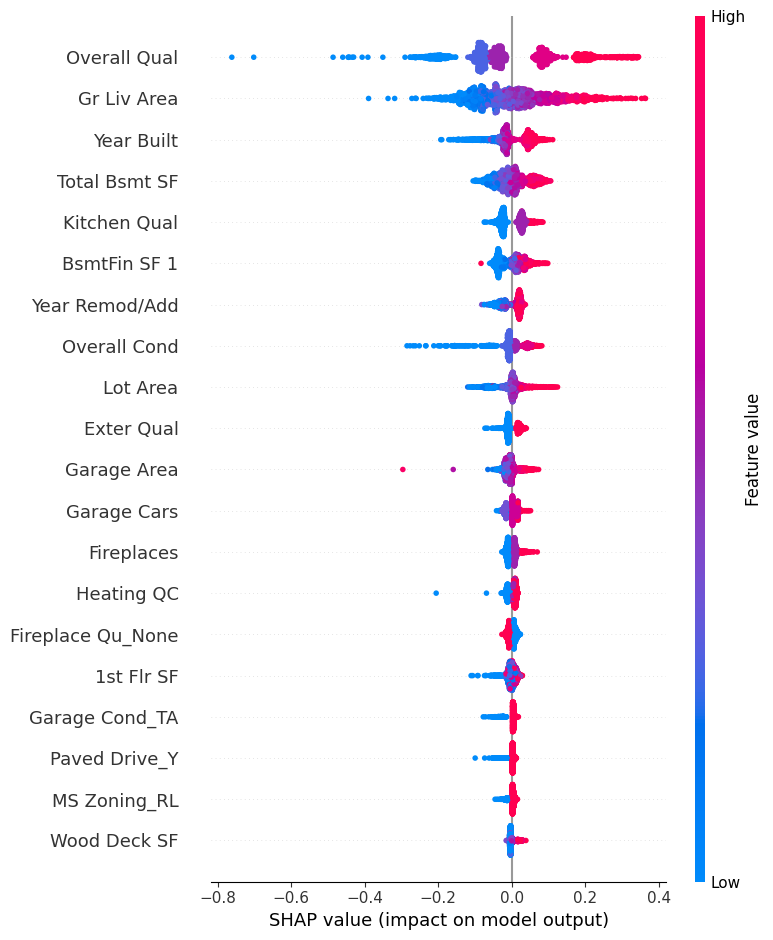

In [ ]:
# Gradien Boosting
explainer_gb = shap.TreeExplainer(gb_best)
shap_values_gb = explainer_gb.shap_values(X_train)

shap.summary_plot(
    shap_values_gb,
    X_train,
    feature_names=X_train.columns
)


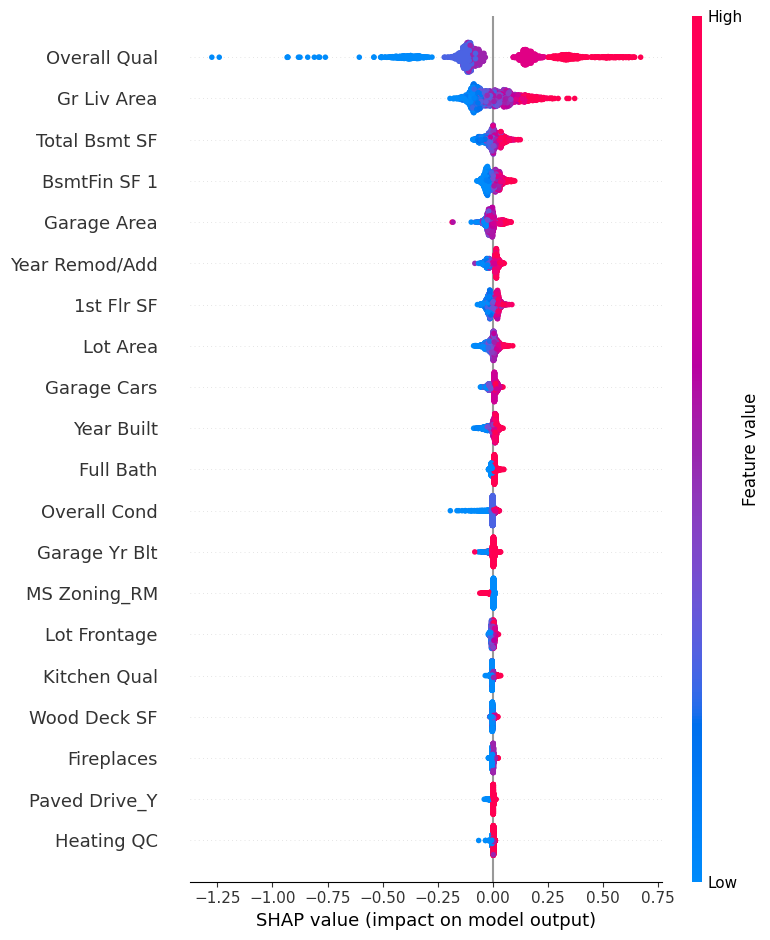

In [ ]:
#Random Forest
explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf = explainer_rf.shap_values(X_train)

shap.summary_plot(
    shap_values_rf,
    X_train,
    feature_names=X_train.columns
)


## Task 3: Neural Networks
Goal: To design and train a Feed-Forward Neural Network and Autoencoder to compare its predictive accuracy against our traditional machine learning models.

In [ ]:
# Feature scaling
scaler = StandardScaler()

X_train_nn = scaler.fit_transform(X_train)
X_test_nn  = scaler.transform(X_test)

X_full_nn = scaler.transform(pd.concat([X_train, X_test], axis=0))


In [ ]:
# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


### Feed-Forward

In [ ]:
# Feed-forward base model
ffnn_base = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

ffnn_base.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_base = ffnn_base.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
best_val_mae = min(history_base.history["val_mae"])
print("Best val MAE:", best_val_mae)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 84.5325 - mae: 8.5158 - val_loss: 3.0117 - val_mae: 1.3501
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0100 - mae: 1.0915 - val_loss: 1.3092 - val_mae: 0.8614
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0156 - mae: 0.7589 - val_loss: 0.9589 - val_mae: 0.7221
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7255 - mae: 0.6339 - val_loss: 0.8092 - val_mae: 0.6589
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5012 - mae: 0.5306 - val_loss: 0.6921 - val_mae: 0.6116
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4407 - mae: 0.5013 - val_loss: 0.6026 - val_mae: 0.5768
Epoch 7/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3923 - mae: 0.4723 - val_loss: 0.5266 - val_mae: 0.5295
Epoch 8/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3062 - mae: 0.4196 - val_loss: 0.4991 - val_mae: 0.5138
Epoch 9/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.25

In [ ]:
y_pred_base = ffnn_base.predict(X_test_nn).ravel()

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)

print(f"FFNN → RMSE: {rmse_base:.3f}, MAE: {mae_base:.3f}, R2: {r2_base:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
FFNN → RMSE: 0.417, MAE: 0.269, R2: -0.050


Since base FFNN performance results are not as nearly good as for shallow learners, we will aply both regularization, normalization and dropout to test if can get better results.

In [ ]:
# Normalization and Improvements
ffnn_imp = Sequential([
    Dense(256, activation='relu', kernel_regularizer=l2(0.001),
          input_shape=(X_train_nn.shape[1],)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(1)
])

ffnn_imp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_imp = ffnn_imp.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
best_val_mae = min(history_imp.history["val_mae"])
print("Best val MAE:", best_val_mae)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 141.2311 - mae: 11.7878 - val_loss: 113.4556 - val_mae: 10.6343
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 117.4760 - mae: 10.7361 - val_loss: 82.6793 - val_mae: 9.0670
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 84.7317 - mae: 9.0274 - val_loss: 45.4077 - val_mae: 6.6918
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.2360 - mae: 6.3403 - val_loss: 14.6553 - val_mae: 3.7123
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16.5153 - mae: 3.5356 - val_loss: 2.7800 - val_mae: 1.3892
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9501 - mae: 2.0440 - val_loss: 1.2552 - val_mae: 0.8065
Epoch 7/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.7942 - mae: 1.8238 - val_loss: 1.5911 - val_mae: 0.7755
Epoch 8/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6306 - mae: 1.7387 - val_loss: 1.0168 - val_mae: 0.6659
Epoch 9/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.

In [ ]:
y_pred_imp = ffnn_imp.predict(X_test_nn).ravel()

rmse_imp = np.sqrt(mean_squared_error(y_test, y_pred_imp))
mae_imp  = mean_absolute_error(y_test, y_pred_imp)
r2_imp   = r2_score(y_test, y_pred_imp)

print(f"FFNN Improved → RMSE: {rmse_imp:.3f}, MAE: {mae_imp:.3f}, R2: {r2_imp:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
FFNN Improved → RMSE: 0.132, MAE: 0.096, R2: 0.895


### Model comparison

In [ ]:
print(f"FFNN → RMSE: {rmse_base:.3f}, MAE: {mae_base:.3f}, R2: {r2_base:.3f}")
print(f"FFNN Improved → RMSE: {rmse_imp:.3f}, MAE: {mae_imp:.3f}, R2: {r2_imp:.3f}")


FFNN → RMSE: 0.417, MAE: 0.269, R2: -0.050
FFNN Improved → RMSE: 0.132, MAE: 0.096, R2: 0.895


After introducing regularization, improved architecture, and hyperparameter tuning the FFNN achieved a substantial improvement in all three metrics, indicating sucesfull nonlinear relationship training. Though the results are still below all of the shalow learners.

### Training Curves
Below are the training and validation loss plots. We look for a smooth decline in both metrics, which confirms that the Early Stopping and Dropout layers are effectively regularizing the model and preventing it from becoming overly complex for this dataset.

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['mae'], label='train')
    plt.plot(history.history['val_mae'], label='val')
    plt.title(f'{title} - MAE')
    plt.legend()

    plt.show()


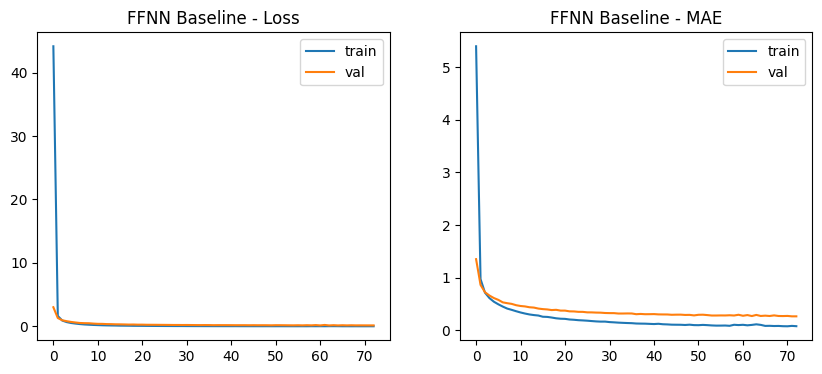

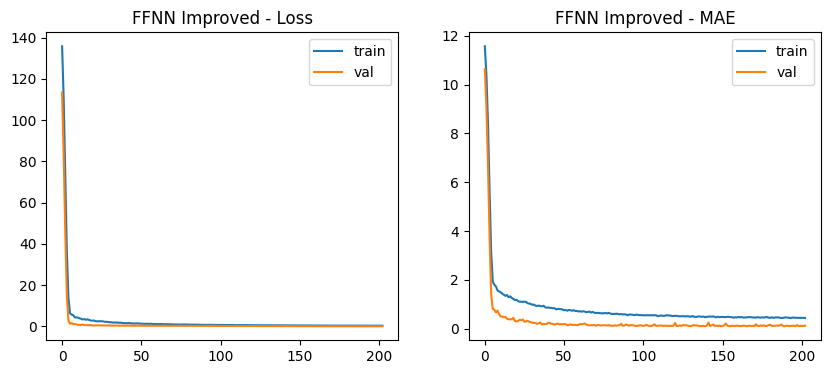

In [ ]:
plot_history(history_base, "FFNN Baseline")
plot_history(history_imp, "FFNN Improved")


The improved FFNN exhibits smoother convergence, lower validation error, and a controlled gap between training and validation metrics, suggesting improved generalization.

### Autoencoder
Having explored supervised learning models, we now transition to Unsupervised Feature Learning using an Autoencoder. The goal is to compress our high-dimensional house features into a lower-dimensional 'latent space' (bottleneck) that captures the most essential, non-linear representations of the data. By reconstructing the input, the model learns to ignore noise and highlight the core structural characteristics, which we can then use to potentially enhance our final price predictions.

In [ ]:

input_dim = X_train_nn.shape[1]
latent_dim = 20

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(latent_dim, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

history_ae = autoencoder.fit(
    X_full_nn, X_full_nn,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9519 - val_loss: 0.6900
Epoch 2/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6511 - val_loss: 0.5420
Epoch 3/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5192 - val_loss: 0.4583
Epoch 4/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4507 - val_loss: 0.4051
Epoch 5/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3888 - val_loss: 0.3673
Epoch 6/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3554 - val_loss: 0.3347
Epoch 7/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3335 - val_loss: 0.3095
Epoch 8/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3106 - val_loss: 0.2916
Epoch 9/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2835 - val_loss: 0.2786
Epoch 10/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2688 - val_loss: 0.2617
Epoch 11/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2584 - val_loss: 0.2522
Epoch 12/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2

In [ ]:
X_train_latent = encoder.predict(X_train_nn)
X_test_latent  = encoder.predict(X_test_nn)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
min(history_ae.history["val_loss"])


0.0950789526104927

### RF on latent features

In [ ]:
# Making autoncoder predictable
rf_latent = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_latent.fit(X_train_latent, y_train)

y_pred_latent = rf_latent.predict(X_test_latent)

rmse_latent = np.sqrt(mean_squared_error(y_test, y_pred_latent))
mae_latent  = mean_absolute_error(y_test, y_pred_latent)
r2_latent   = rf_latent.score(X_test_latent, y_test)

print(f"RF + Autoencoder → RMSE: {rmse_latent:.3f}, MAE: {mae_latent:.3f}, R2: {r2_latent:.3f}")


RF + Autoencoder → RMSE: 0.145, MAE: 0.109, R2: 0.873


The Random Forest trained on latent features (RMSE: 0.145) did not outperform the original model (RMSE: 0.112). This indicates that while the Autoencoder successfully captured the 'global' structure of the data, the 20-dimensional bottleneck likely filtered out some high-variance, specific details—such as exact neighborhood effects or specific square footage increments—that are critical for precise price estimation. This demonstrates the trade-off between dimensionality reduction and predictive signal loss.

##Conclusion
In conclusion, the Gradient Boosting and Stacked Ensemble models emerged as the superior performers for this dataset, achieving an RMSE of 0.111 and MAE of 0.077. While the Neural Network and Autoencoder offered sophisticated approaches to feature learning, they did not surpass the tree-based ensembles. This suggests that for a dataset of this size and nature, the combination of rigorous feature engineering and ensemble learning provides the most accurate and reliable tool for real estate valuation.